In [1]:
import pandas as pd

data = {
    "Age": [22, 25, 28, 30, 32, 35, 27, 29, 31, 24,
            26, 33, 36, 28, 30, 34, 23, 27, 32, 38],

    "Experience": [1, 2, 4, 5, 7, 10, 3, 5, 6, 2,
                   3, 8, 12, 4, 6, 9, 1, 4, 7, 14],

    "Education": [
        "Bachelor", "Bachelor", "Master", "Master", "Master",
        "Master", "Bachelor", "Master", "Bachelor", "Bachelor",
        "Master", "Master", "Master", "Bachelor", "Master",
        "Master", "Bachelor", "Bachelor", "Master", "Master"
    ],

    "Department": [
        "IT", "HR", "IT", "Finance", "IT",
        "IT", "HR", "Finance", "IT", "HR",
        "Finance", "IT", "IT", "HR", "Finance",
        "IT", "HR", "IT", "Finance", "IT"
    ],

    "Salary": [
        30000, 32000, 45000, 50000, 65000,
        85000, 40000, 55000, 60000, 35000,
        43000, 70000, 95000, 48000, 62000,
        80000, 31000, 42000, 68000, 100000
    ]
}

df = pd.DataFrame(data)

df.head()

,Age,Experience,Education,Department,Salary
0,22,1,Bachelor,IT,30000
1,25,2,Bachelor,HR,32000
2,28,4,Master,IT,45000
3,30,5,Master,Finance,50000
4,32,7,Master,IT,65000


In [2]:
df.isnull().sum()

,0
Age,0
Experience,0
Education,0
Department,0
Salary,0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
X = df.drop("Salary", axis = 1)
y = df["Salary"
]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ValueError: could not convert string to float: 'Bachelor'

In [7]:
X.head()


,Age,Experience,Education,Department
0,22,1,Bachelor,IT
1,25,2,Bachelor,HR
2,28,4,Master,IT
3,30,5,Master,Finance
4,32,7,Master,IT


In [8]:
categorical_cols = ["Education", "Department"]

In [10]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [11]:
X.head()

,Age,Experience,Education_Master,Department_HR,Department_IT
0,22,1,False,False,True
1,25,2,False,True,False
2,28,4,True,False,True
3,30,5,True,False,False
4,32,7,True,False,True


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
9
y_pred


array([30804.1842344 , 48277.09878849, 75764.04974115, 35624.99332871])

In [14]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test ,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2_score:", r2)


MAE: 3735.5566526124594
MSE: 17783133.17799032
RMSE: 4217.005238079545
R2_score: 0.9561991793645559


In [15]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha = 0.1)

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R2:", ridge_r2)

Ridge MAE: 3420.700698667564
Ridge RMSE: 3989.876296837199
Ridge R2: 0.9607903624037849


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)


In [19]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MAE:", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("R2 Score:", lasso_r2)

Lasso MAE: 3732.772756698577
Lasso RMSE: 4214.797761964129
R2 Score: 0.9562450242013354


In [29]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MAE": [mae, ridge_mae, lasso_mae],
    "RMSE": [rmse, ridge_rmse, lasso_rmse],
    "R2 Score": [r2, ridge_r2, lasso_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3735.556653,4217.005238,0.956199
1,Ridge,3420.700699,3989.876297,0.960790
2,Lasso,3732.772757,4214.797762,0.956245


In [31]:
import matplotlib.pyplot as plt


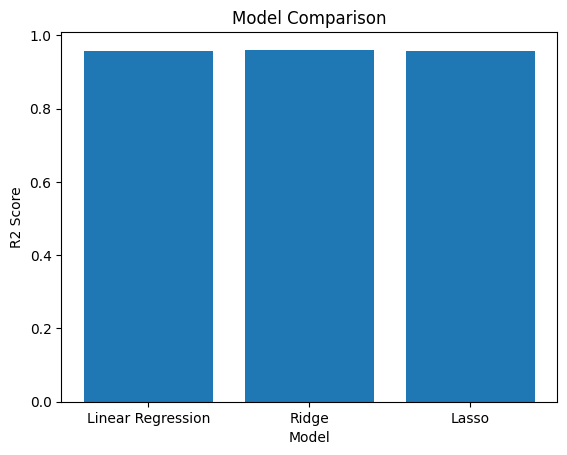

In [32]:
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison")

plt.show()

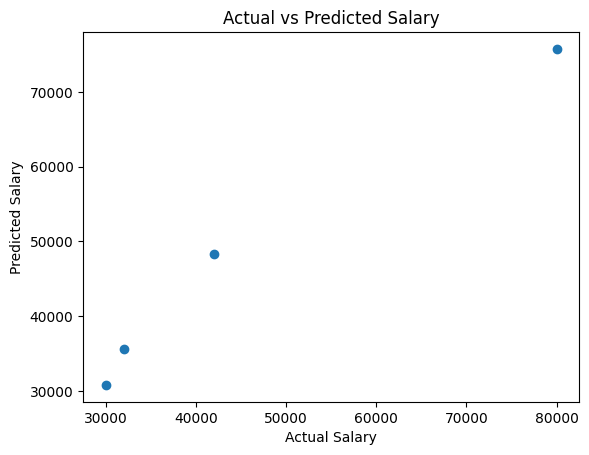

In [33]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [34]:
X_train.columns

Index(['Age', 'Experience', 'Education_Master', 'Department_HR',
       'Department_IT'],
      dtype='object')

In [35]:
new_employee = [[25,9,1,0,1]]
pred_salary = ridge_model.predict(new_employee)
print("Predicted salary:", pred_salary[0])


Predicted salary: 73772.07631935686


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
